# Phase 2 — Data Audit and Exploratory Data Analysis

## Financial NLP for the Crypto Market

This notebook is the **main working artifact** for Phase 2 of the project.

The goal is not to preprocess the text yet and not to train a model. The goal is to understand the raw historical dataset well enough to make defensible decisions for the next phases.

### Current project scope

- Primary asset of interest: **Bitcoin**
- News language: **English**
- Initial model input: **text only**
- Main initial objective: **detect and rank market-impactful news**
- Future market horizons: **1h, 4h, 24h**
- Current historical dataset: **CryptoVision V1**

### Core question of this phase

> **What is actually inside the dataset, how reliable is it, what biases or quality problems exist, and what should we carry into text preprocessing?**

The notebook intentionally does **not** generate a separate audit report. The analysis, figures, explanations, and final decisions stay here so that the research process is transparent and easy to study.

### Table of Content
1. [How this phase fits into the project](#1-how-this-phase-fits-into-the-project)
2. [Audit strategy: sample + full-data streaming](#2-audit-strategy-sample--full-data-streaming)
3. [Locate the repository and import Phase 2 helpers](#3-locate-the-repository-and-import-phase-2-helpers)
4. [Configuration](#4-configuration)
5. [Schema audit](#5-schema-audit)
6. [Fast sample inspection](#6-fast-sample-inspection)
7. [Exact row count](#7-exact-row-count)
8. [Full-dataset missingness](#8-full-dataset-missingness)
9. [Duplicate-news audit](#9-duplicate-news-audit)
10. [Timestamp audit and temporal coverage](#10-timestamp-audit-and-temporal-coverage)
11. [Cryptocurrency coverage and Bitcoin relevance](#11-cryptocurrency-coverage-and-bitcoin-relevance)
12. [Source-domain distribution](#12-source-domain-distribution)
13. [Random text sample for NLP-oriented EDA](#13-random-text-sample-for-nlp-oriented-eda)
14. [Text completeness, length, and noise](#14-text-completeness-length-and-noise)
15. [Approximate duplicate-title analysis on the random sample](#15-approximate-duplicate-title-analysis-on-the-random-sample)
16. [Publisher-generated sentiment labels](#16-publisher-generated-sentiment-labels)
17. [Publisher-generated market classes](#17-publisher-generated-market-classes)
18. [OHLCV and market-field sanity checks](#18-ohlcv-and-market-field-sanity-checks)
19. [Numeric EDA on a random sample](#19-numeric-eda-on-a-random-sample)
20. [Handoff to Phase 3 — Text Preprocessing](#20-handoff-to-phase-3--text-preprocessing)

## 1. How this phase fits into the project

The project pipeline is:

```text
0_project_definition
1_data_acquisition
2_data_audit_and_eda          <- current phase
3_text_preprocessing
4_nlp_feature_extraction
5_market_alignment_and_labeling
6_dataset_splitting_and_leakage_control
7_model_selection_and_training
8_evaluation_and_error_analysis
9_news_ranking_and_event_analysis
10_application_and_live_pipeline
11_documentation_and_reproducibility
```

### Important boundary

Phase 1 already contains a lightweight `inspect_dataset.py`. That script answers operational questions such as:

- Does the file exist?
- Can Pandas parse it?
- What are the first columns and rows?
- Are there obvious nulls in a small sample?

Phase 2 answers **research and modeling questions**, for example:

- Does the full dataset contain large missingness patterns?
- Are news URLs duplicated?
- Is the time coverage reliable?
- Which publishers dominate the data?
- How much of the dataset is relevant to Bitcoin?
- Which text field should be considered for Phase 3?
- Are publisher-provided sentiment/market columns safe to use?

This distinction prevents duplication between acquisition and EDA.

## 2. Audit strategy: sample + full-data streaming

CryptoVision V1 is large enough that loading the entire CSV into memory is unnecessary for most checks.

We therefore use two strategies.

### Strategy A — small/random sample

Best for:

- inspecting example records,
- text-length analysis,
- text-noise analysis,
- descriptive numeric distributions,
- visual exploration.

### Strategy B — chunked full-data checks

Best for quantities that must represent the whole dataset:

- total row count,
- missingness,
- duplicate article identities,
- category frequencies,
- timestamp parsing,
- source-domain frequencies,
- OHLCV sanity checks.

This is an important data-engineering pattern: **use the full dataset when the statistic must be exact, but do not keep the full dataset in RAM if you do not need to.**

In [1]:
# Standard-library imports
from pathlib import Path
import sys

# Data-science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.5
NumPy: 2.5.1


## 3. Locate the repository and import Phase 2 helpers

The notebook should work whether Jupyter is launched from the repository root or from the notebook folder.

We detect the root by searching upward for `1_data_acquisition`, then add the Phase 2 directory to Python's import path.

In [2]:
def locate_project_root(start: Path | None = None) -> Path:
    """Locate the repository root by finding the 1_data_acquisition folder."""
    start_path = (start or Path.cwd()).resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "1_data_acquisition").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook inside the project repository."
    )


PROJECT_ROOT = locate_project_root()
PHASE2_DIR = PROJECT_ROOT / "2_data_audit_and_eda"

if str(PHASE2_DIR) not in sys.path:
    sys.path.insert(0, str(PHASE2_DIR))

from src.audit_utils import (
    V1_EXPECTED_COLUMNS,
    POTENTIAL_LEAKAGE_COLUMNS,
    resolve_historical_dataset,
    file_metadata,
    read_header,
    load_sample,
    schema_audit,
    row_count_streaming,
    missingness_streaming,
    duplicate_key_audit,
    datetime_audit,
    value_counts_streaming,
    source_domain_counts,
    reservoir_sample_csv,
    financial_sanity_checks,
    leakage_review,
)

from src.eda_utils import (
    text_quality_summary,
    normalized_title_duplicate_summary,
    numeric_summary,
    plot_missingness,
    plot_top_counts,
    plot_records_by_year,
    plot_text_length_histograms,
)


## 4. Configuration

CryptoVision V1 is the **pinned primary dataset** for the current project version.

CryptoVision V2 may also have been downloaded by Phase 1, but it is not silently substituted for V1 because the publisher changed the released structure and preprocessing in V2.

The acquisition phase currently stores files in a directory named `row`. The helper also supports `raw` as a future fallback if that folder is renamed.

In [3]:
# Primary dataset used by this project version.
PRIMARY_FILENAME = "cryptovision_v1.csv"

# Optional comparison dataset.
V2_FILENAME = "cryptovision_v2.csv"

# Notebook execution settings.
FAST_SAMPLE_ROWS = 1_000
RANDOM_TEXT_SAMPLE_ROWS = 20_000
CHUNK_SIZE = 5_000
RUN_OPTIONAL_V2_COMPARISON = True

V1_PATH = resolve_historical_dataset(PROJECT_ROOT, PRIMARY_FILENAME)
V2_PATH = resolve_historical_dataset(PROJECT_ROOT, V2_FILENAME)

print("V1 path:", V1_PATH)
print("V1 exists:", V1_PATH.exists())
print("V2 path:", V2_PATH)
print("V2 exists:", V2_PATH.exists())

if not V1_PATH.exists():
    raise FileNotFoundError(
        f"Primary dataset not found: {V1_PATH}\n"
        "Run 1_data_acquisition/historical/download_datasets.py first."
    )

v1_file_info = file_metadata(V1_PATH)
pd.DataFrame([v1_file_info])

V1 path: C:\Users\sepehr\PycharmProjects\FinancialNLP\1_data_acquisition\historical\row\cryptovision_v1.csv
V1 exists: True
V2 path: C:\Users\sepehr\PycharmProjects\FinancialNLP\1_data_acquisition\historical\row\cryptovision_v2.csv
V2 exists: True


,path,filename,size_bytes,size_mb,size_gb
0,C:\Users\sepehr\PycharmProjects\FinancialNLP\1_data_acquisition\historical\row\cryptovision_v1.csv,cryptovision_v1.csv,891728566,850.4186,0.8305


## 5. Schema audit

### Question

Did Phase 1 produce a real, non-empty file at the expected location?

### Why it matters

A model cannot compensate for a wrong download, unexpected filename, or corrupted/empty source file. File-level validation is the first boundary between acquisition and analysis.

In [4]:
v1_columns = read_header(V1_PATH)

print(f"Observed number of columns: {len(v1_columns)}")
print("Observed columns:")
for index, column in enumerate(v1_columns, start=1):
    print(f"{index:>2}. {column}")

schema_result = schema_audit(v1_columns, V1_EXPECTED_COLUMNS)
schema_result

Observed number of columns: 17
Observed columns:
 1. URL
 2. Title
 3. Description
 4. Full Text
 5. Date Time
 6. Coin Type
 7. Filtered_Text
 8. sentiment_label
 9. sentiment_score
10. Open
11. High
12. Low
13. Close
14. Volume
15. Movement_OpenClose_%
16. Movement_HighLow_%
17. Market_Move


,column,expected,present,position_expected,position_actual
0,URL,True,True,1,1
1,Title,True,True,2,2
2,Description,True,True,3,3
3,Full Text,True,True,4,4
4,Date Time,True,True,5,5
5,Coin Type,True,True,6,6
6,Filtered_Text,True,True,7,7
7,sentiment_label,True,True,8,8
8,sentiment_score,True,True,9,9
9,Open,True,True,10,10


In [5]:
missing_expected_columns = schema_result.query("expected == True and present == False")
unexpected_columns = schema_result.query("expected == False and present == True")

print("Missing expected columns:", missing_expected_columns["column"].tolist())
print("Unexpected columns:", unexpected_columns["column"].tolist())

Missing expected columns: []
Unexpected columns: []


### Decision rule

- If expected columns are missing, do **not** immediately patch the notebook. First verify that the correct dataset version was downloaded.
- Extra columns are not automatically bad, but they must be documented before use.
- Phase 3 should depend only on columns that are explicitly understood.

## 6. Fast sample inspection

A small sample is useful for understanding the shape and examples of the data before running full-dataset checks.

**Important:** the first rows are *not* treated as a statistically representative sample. They are used only for fast structural inspection.

In [6]:
df_head_sample = load_sample(V1_PATH, nrows=FAST_SAMPLE_ROWS)

print("Sample shape:", df_head_sample.shape)
display(df_head_sample.head(3))

Sample shape: (1000, 17)


,URL,Title,Description,Full Text,Date Time,Coin Type,Filtered_Text,sentiment_label,sentiment_score,Open,High,Low,Close,Volume,Movement_OpenClose_%,Movement_HighLow_%,Market_Move
0,https://cryptopanic.com/news/12958/Anonymous-Email-Service-ProtonMail-Adds-Bitcoin-Payment-Option,Anonymous Email Service ProtonMail Adds Bitcoin Payment Option,"ProtonMail has revealed it is adding bitcoin as an official, automated payment option – and other cryptocurrencies m...","ProtonMail has revealed it is adding bitcoin as an official, automated payment option – and other cryptocurrencies m...",2017-08-17 15:00:33+00:00,Bitcoin,protonmail revealed adding official automated payment option cryptocurrencies may soon follow,NEGATIVE,0.9897,"4,470.8200","4,470.8200","4,453.6700","4,460.0000",9.8029,-0.2420,0.3851,Down
1,https://cointelegraph.com/press-releases/blockchain-bitcoin-conference-stockholm-to-feature-discussions-on-icos-and-...,Blockchain & Bitcoin Conference Stockholm to Feature Discussions on ICOs and Blockchain Development,NaN,"On September 7, Stockholm will host a large conference dedicated to blockchain technology, cryptocurrencies, and ICO...",2017-08-17 16:30:00+00:00,Bitcoin,september stockholm host large conference dedicated blockchain technology cryptocurrencies icos blockchain conferenc...,POSITIVE,0.9946,"4,290.1700","4,337.2900","4,290.1700","4,300.2900",8.1158,0.2359,1.0983,Up
2,https://cryptopanic.com/news/12971/Bitcoin-Prices-Reach-New-All-Time-High-of-Over-4500,"Bitcoin Prices Reach New All-Time High of Over $4,500","Following two days of sideways trading, bitcoin prices have once again reached record levels.","Following two days of sideways trading, bitcoin prices have once again reached record levels.",2017-08-17 16:34:35+00:00,Bitcoin,following two days sideways trading prices reached record levels,NEGATIVE,0.9897,"4,290.1700","4,337.2900","4,290.1700","4,300.2900",8.1158,0.2359,1.0983,Up


In [7]:
sample_dtypes = pd.DataFrame({
    "column": df_head_sample.columns,
    "dtype_in_sample": df_head_sample.dtypes.astype(str).values,
    "missing_in_sample": df_head_sample.isna().sum().values,
    "unique_in_sample": df_head_sample.nunique(dropna=False).values,
})

sample_dtypes

,column,dtype_in_sample,missing_in_sample,unique_in_sample
0,URL,str,0,931
1,Title,str,0,927
2,Description,str,156,802
3,Full Text,str,0,927
4,Date Time,str,0,929
5,Coin Type,str,0,3
6,Filtered_Text,str,0,965
7,sentiment_label,str,0,2
8,sentiment_score,float64,0,960
9,Open,float64,0,961


### What not to conclude from this sample

Do not use the first 1,000 rows to make final statements about:

- class balance,
- source distribution,
- Bitcoin coverage,
- time coverage,
- full-dataset missingness.

Those require full-data calculations below.

## 7. Exact row count

### Question

How many rows are actually present in the downloaded file?

The publisher's metadata is useful as a reference, but the local file should be verified independently.

In [8]:
total_rows = row_count_streaming(V1_PATH, chunksize=50_000)
print(f"Total rows in local V1 CSV: {total_rows:,}")

Total rows in local V1 CSV: 188,430


## 8. Full-dataset missingness

### Question

Which variables are incomplete, and how severe is the missingness?

### Why it matters

Missing text can make a news item unusable for NLP. Missing timestamps make event alignment impossible. Missing market values may invalidate publisher-provided market annotations.

This check scans the full CSV in chunks.

In [9]:
missingness = missingness_streaming(V1_PATH, chunksize=CHUNK_SIZE)
missingness

,column,missing_count,missing_pct,total_rows
0,Description,29554,15.6843,188430
1,Title,296,0.1571,188430
2,Market_Move,2,0.0011,188430
3,sentiment_label,2,0.0011,188430
4,Filtered_Text,2,0.0011,188430
5,sentiment_score,2,0.0011,188430
6,Movement_OpenClose_%,2,0.0011,188430
7,Movement_HighLow_%,2,0.0011,188430
8,Close,2,0.0011,188430
9,Volume,2,0.0011,188430


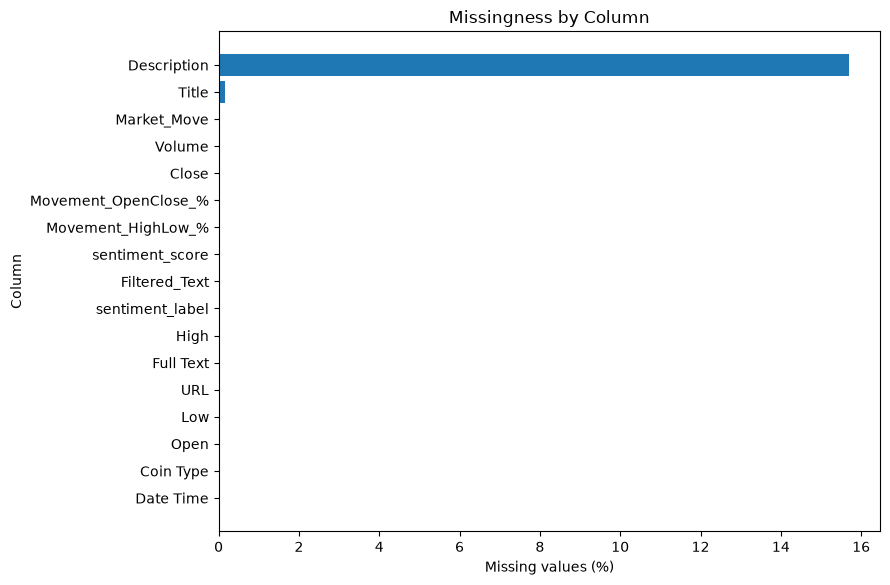

In [10]:
plot_missingness(missingness)

### Interpretation checklist

Pay special attention to:

- `Title`: critical for almost every planned model.
- `Description`: important if we use `Title + Description`.
- `Full_Text`: may be missing or noisy and is expensive to model.
- `Date_Time`: mandatory for future event/market alignment.
- `Coin_Type`: useful for restricting the current project to Bitcoin.
- market fields: useful for audit, but not automatically accepted as this project's final labels.


## 9. Duplicate-news audit

### Question

Does the same underlying article appear multiple times?

### Why use URL as the primary identity key?

Two rows can refer to the same news article even if some downstream columns differ. URL duplication is therefore often more meaningful than asking whether every cell in two rows is identical.

Duplicates are dangerous because they can:

- inflate dataset size,
- overrepresent particular events,
- contaminate train/test splits,
- make evaluation look better if near-identical news appears on both sides of a split.

In [11]:
if "URL" in v1_columns:
    duplicate_url_result = duplicate_key_audit(
        V1_PATH,
        columns=["URL"],
        chunksize=20_000,
    )
    display(pd.DataFrame([duplicate_url_result]))
else:
    print("URL column is not available; URL-based duplicate audit was skipped.")

,columns,total_rows,unique_keys,duplicate_rows,duplicate_pct
0,[URL],188430,119558,68872,36.5504


In [12]:
if all(column in v1_columns for column in ["URL", "Title"]):
    duplicate_url_title_result = duplicate_key_audit(
        V1_PATH,
        columns=["URL", "Title"],
        chunksize=20_000,
    )
    display(pd.DataFrame([duplicate_url_title_result]))

,columns,total_rows,unique_keys,duplicate_rows,duplicate_pct
0,"[URL, Title]",188430,119559,68871,36.5499


### Important methodological note

Do **not** delete duplicates in this notebook.

Phase 2 diagnoses the problem. The exact deduplication rule belongs to Phase 3 because we must decide whether duplicates mean:

- exact repeated rows,
- the same URL,
- normalized duplicate titles,
- syndication of the same event across different publishers,
- or legitimate repeated reporting over time.

Those cases should not all be treated identically.

## 10. Timestamp audit and temporal coverage

### Question

Can publication timestamps be parsed reliably, and what time period is actually covered?

### Why it matters for Financial NLP

This project eventually studies **market reaction after news publication**. A bad timestamp can attach a news article to the wrong market interval.

Time coverage also affects model evaluation. If some years dominate the dataset, a random split can hide regime changes and create overly optimistic results.

In [13]:
if "Date Time" in v1_columns:
    datetime_summary, records_by_year, records_by_month = datetime_audit(
        V1_PATH,
        column="Date Time",
        chunksize=20_000,
    )

    display(pd.DataFrame([datetime_summary]))
    display(records_by_year)
    display(records_by_month.tail(12))
else:
    datetime_summary = {}
    records_by_year = pd.DataFrame()
    records_by_month = pd.DataFrame()
    print("Date_Time column is not available.")

,column,total_rows,missing_count,invalid_non_missing_count,parse_success_pct_non_missing,min_datetime_utc,max_datetime_utc
0,Date Time,188430,1,0,100.0000,2017-08-17 15:00:33+00:00,2025-08-27 17:47:34+00:00


,year,count
0,2017,1140
1,2018,6942
2,2019,14291
3,2020,19355
4,2021,27948
5,2022,30643
6,2023,29121
7,2024,33888
8,2025,25101


,month,count
85,2024-09,2680
86,2024-10,2897
87,2024-11,2884
88,2024-12,3053
89,2025-01,2756
90,2025-02,3094
91,2025-03,3785
92,2025-04,3553
93,2025-05,3516
94,2025-06,3418


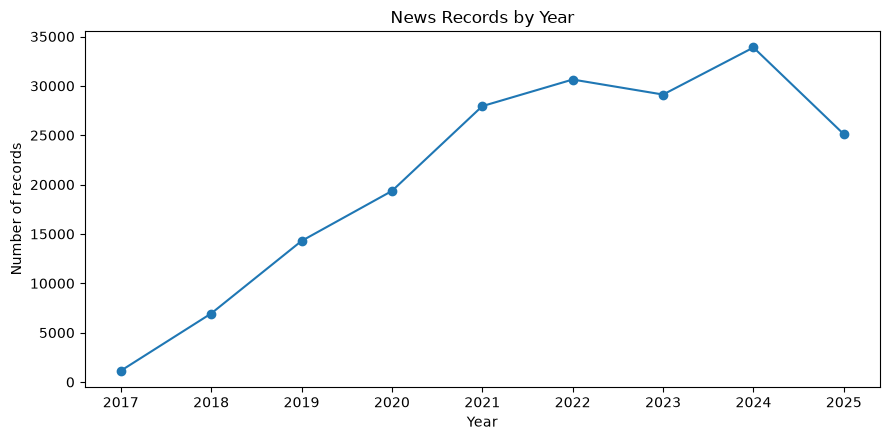

In [14]:
if not records_by_year.empty:
    plot_records_by_year(records_by_year)

### Questions to ask after seeing the plot

- Are some years almost absent?
- Is there a sudden jump in collection volume that could indicate a scraper/source change?
- Are the latest years much more represented than earlier years?
- Does the date range match the publisher's description?

These observations matter later when we design a **time-aware train/validation/test split** in Phase 6.

## 11. Cryptocurrency coverage and Bitcoin relevance

### Question

How much of this multi-crypto news dataset is relevant to Bitcoin?

The current project scope is Bitcoin, so we need to understand how the dataset encodes cryptocurrency categories before filtering anything.

,Coin Type,count
0,Bitcoin,90346
1,Ethereum,38175
2,Solana,17348
3,Ripple,6545
4,Polygon,5179
5,Dogecoin,4913
6,Cardano,3936
7,Terra,3606
8,Avalanche,3176
9,Litecoin,2840


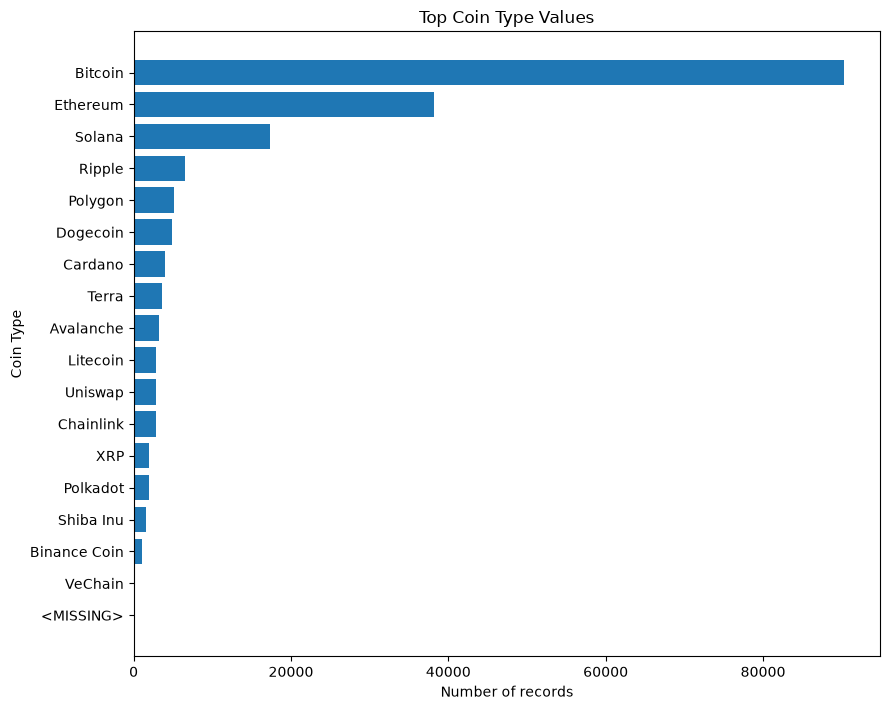

In [15]:
if "Coin Type" in v1_columns:
    coin_counts = value_counts_streaming(
        V1_PATH,
        column="Coin Type",
        chunksize=20_000,
        dropna=False,
    )
    display(coin_counts.head(50))
    plot_top_counts(
        coin_counts,
        category_column="Coin Type",
        top_n=20,
        title="Top Coin Type Values",
    )
else:
    coin_counts = pd.DataFrame()
    print("Coin Type column is not available.")

In [16]:
if not coin_counts.empty:
    coin_labels = coin_counts["Coin Type"].astype(str).str.lower()
    bitcoin_mask = coin_labels.str.contains(r"bitcoin|\bbtc\b", regex=True, na=False)

    bitcoin_encoded_rows = int(coin_counts.loc[bitcoin_mask, "count"].sum())
    total_counted_rows = int(coin_counts["count"].sum())

    print(f"Rows in Coin Type categories explicitly matching Bitcoin/BTC: {bitcoin_encoded_rows:,}")
    print(f"Share of counted rows: {bitcoin_encoded_rows / total_counted_rows * 100:.2f}%")
    print("Matching category labels:")
    display(coin_counts.loc[bitcoin_mask])

Rows in Coin Type categories explicitly matching Bitcoin/BTC: 90,346
Share of counted rows: 47.95%
Matching category labels:


,Coin Type,count
0,Bitcoin,90346


### Caution

`Coin Type` should be audited before it becomes the only Bitcoin filter.

A general-market article may affect Bitcoin even if its category is not literally `Bitcoin`. Conversely, an article tagged with multiple coins may need special treatment.



## 12. Source-domain distribution

### Question

Are news sources balanced, or does one publisher dominate the dataset?

### Why it matters

A model can accidentally learn **publisher style** instead of market-relevant semantics. Source imbalance can also bias language, article length, topic coverage, and publication timing.

The source is derived from the `URL` field.

,domain,count
0,coindesk.com,57164
1,cointelegraph.com,50563
2,cryptopanic.com,28660
3,decrypt.co,21071
4,cryptonews.com,18777
5,blockworks.co,12194


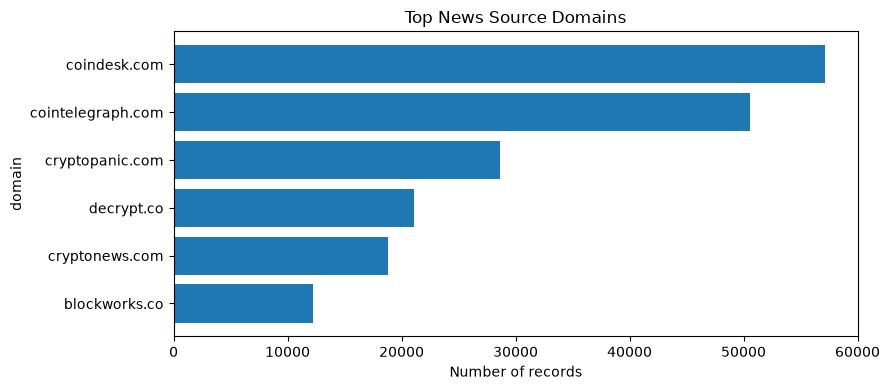

In [17]:
if "URL" in v1_columns:
    domain_counts = source_domain_counts(
        V1_PATH,
        url_column="URL",
        chunksize=20_000,
    )
    display(domain_counts.head(20))
    plot_top_counts(
        domain_counts,
        category_column="domain",
        top_n=15,
        title="Top News Source Domains",
    )
else:
    domain_counts = pd.DataFrame()
    print("URL column is not available.")

### Interpretation

If one source dominates heavily, later error analysis should be stratified by source. It may also be useful to check whether model performance collapses on publishers that were rare during training.



## 13. Random text sample for NLP-oriented EDA

The first rows of a file may be ordered by time or source. For text analysis, we therefore build a **streaming random sample**.

The helper assigns a random priority to each row while scanning the CSV and retains only the requested number of rows. This gives a much better sample for EDA without loading the entire file into memory.

In [18]:
candidate_text_columns = [
    column
    for column in [
        "URL",
        "Title",
        "Description",
        "Full Text",
        "Filtered_Text",
        "Date_Time",
        "Coin_Type",
        "Sentiment_Label",
        "Sentiment_Score",
        "Market_Move",
    ]
    if column in v1_columns
]

text_sample = reservoir_sample_csv(
    V1_PATH,
    n=RANDOM_TEXT_SAMPLE_ROWS,
    columns=candidate_text_columns,
    chunksize=CHUNK_SIZE,
    random_state=42,
)

print("Random text sample shape:", text_sample.shape)
display(text_sample.head(3))

Random text sample shape: (20000, 6)


,URL,Title,Description,Full Text,Filtered_Text,Market_Move
0,https://cryptopanic.com/news/4830143/Bitcoin-Ether-and-XRP-Weekly-Market-Update-March-14-2019,"Bitcoin, Ether, and XRP Weekly Market Update March 14, 2019",The total crypto market cap remained flat for the seven-day period and still stands at $134.5. By the time of writin...,The total crypto market cap remained flat for the seven-day period and still stands at $134.5. By the time of writin...,time writing btc trading ether stands btc/usd managed climb bitfinex daily chart march butread moreread post georgi ...,Down
1,https://cointelegraph.com/news/buyers-shell-out-7m-for-unseen-nft-collection,Buyers shell out $7M for unseen NFT collection,Participants piled $7 million into a Dutch auction to win one of 50 Golden Tokens granting ownership to unminted NFT...,Participants piled $7 million into a Dutch auction to win one of 50 Golden Tokens granting ownership to unminted NFT...,collection sold roughly showcased generative nft platform art blocks september solana-based nft project solblocks ca...,Down
2,https://cryptopanic.com/news/6743898/Ripple-Could-Be-Doing-Massive-Rebranding-While-Community-Argues-about-1-Bln-XRP...,Ripple Could Be Doing Massive Rebranding While Community Argues about 1 Bln XRP Release from Escrow,The Ripple community is having heated discussions over the recent 1 bln XRP release and Ripple removes links to its ...,The Ripple community is having heated discussions over the recent 1 bln XRP release and Ripple removes links to its ...,ripple community heated discussions recent bln xrp release ripple removes links products xrapid xcurrent xvia,Down


## 14. Text completeness, length, and noise

### Question

Which textual representation is most usable for the initial NLP experiments?

Possible V1 fields include:

- `Title`
- `Description`
- `Full Text`
- `Filtered_Text`

For each field we inspect:

- missing/empty rows,
- character length,
- word length,
- HTML-like content,
- embedded URLs,
- repeated whitespace.

### Why this matters

The longest field is not automatically the best field. Full article text may contain more information but also more boilerplate, copyright-sensitive content, duplicated material, and computational cost.

Likewise, `Filtered_Text` was preprocessed by the dataset publisher. Using it blindly can hide important preprocessing decisions that this educational project is supposed to learn and control.

In [19]:
text_columns = [
    column
    for column in ["Title", "Description", "Full Text", "Filtered_Text"]
    if column in text_sample.columns
]

text_quality = text_quality_summary(text_sample, text_columns)
text_quality

,column,rows,missing_count,empty_after_strip_count,median_chars_non_empty,mean_chars_non_empty,median_words_non_empty,html_like_pct,url_like_pct,repeated_whitespace_pct
0,Title,20000,30,30,69.0000,68.8981,11.0000,0.0000,0.0100,0.3000
1,Description,20000,3138,3138,135.0000,158.7659,21.0000,0.0050,0.1950,1.2350
2,Full Text,20000,0,0,"2,982.0000","3,487.5008",464.0000,0.0700,10.5950,52.7700
3,Filtered_Text,20000,0,0,395.0000,795.3210,51.0000,0.0000,0.0350,0.0000


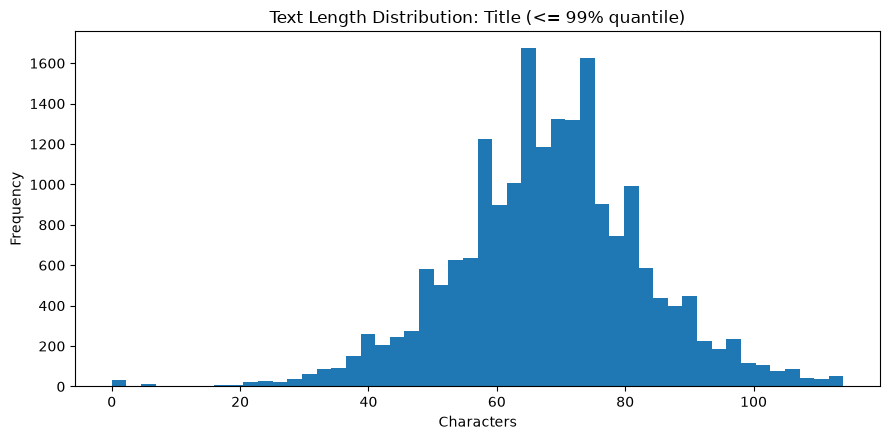

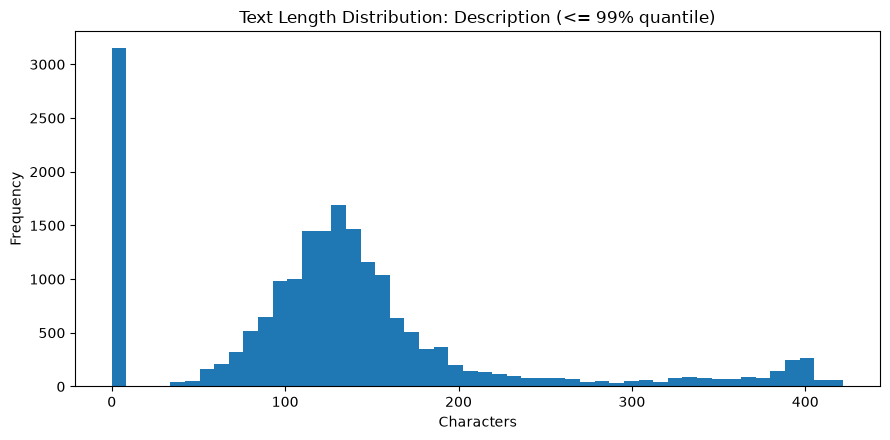

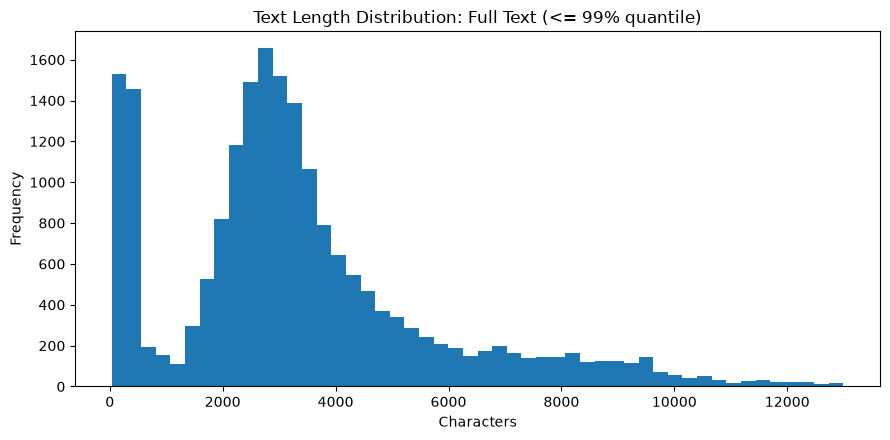

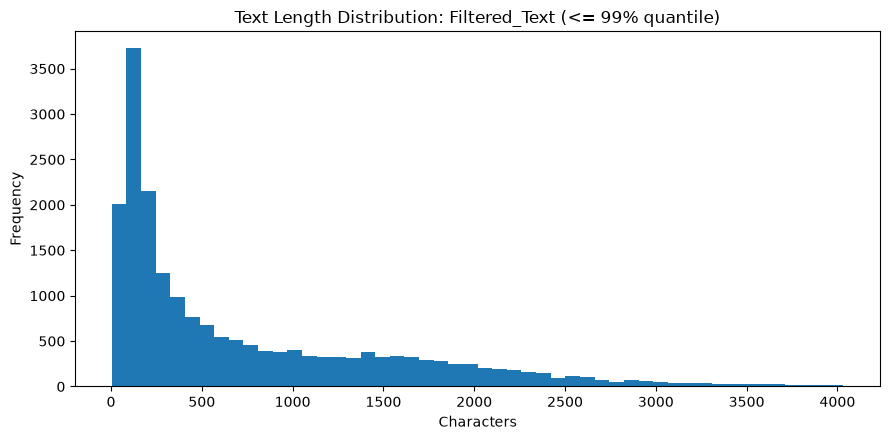

In [20]:
plot_text_length_histograms(text_sample, text_columns, max_quantile=0.99)

## 15. Approximate duplicate-title analysis on the random sample

URL duplicates detect repeated article identities. Normalized titles help reveal another pattern: repeated or near-repeated headlines.

This cell performs only conservative normalization (lowercase, trim, collapse whitespace). It does **not** perform semantic deduplication.

In [21]:
title_duplicate_sample = normalized_title_duplicate_summary(text_sample, column="Title")
pd.DataFrame([title_duplicate_sample])

,rows,non_missing_titles,duplicate_title_rows,duplicate_title_pct
0,20000,19970,1273,6.3746


## 16. Publisher-generated sentiment labels

### Question

What is the class distribution of the provided sentiment annotation?

### Important boundary

These labels are useful for understanding the dataset, but the project's main initial task is **market impact**, not reproducing the publisher's sentiment classifier.

They must therefore not silently become the target variable just because they already exist.

,sentiment_label,count
0,NEGATIVE,147514
1,POSITIVE,40914
2,<MISSING>,2


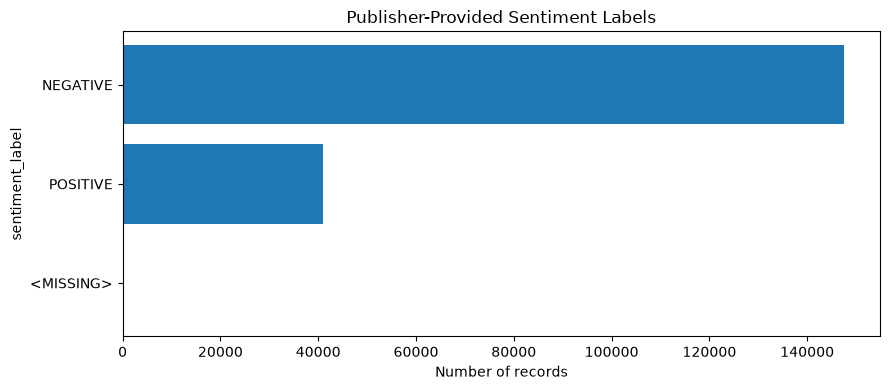

In [22]:
if "sentiment_label" in v1_columns:
    sentiment_counts = value_counts_streaming(
        V1_PATH,
        column="sentiment_label",
        chunksize=20_000,
        dropna=False,
    )
    display(sentiment_counts)
    plot_top_counts(
        sentiment_counts,
        category_column="sentiment_label",
        top_n=10,
        title="Publisher-Provided Sentiment Labels",
    )
else:
    sentiment_counts = pd.DataFrame()
    print("sentiment_label column is not available.")

### What to learn from this

- Severe class imbalance would matter if sentiment classification becomes a secondary experiment.
- The existence of `Sentiment_Score` does not make it a safe feature for a text-only baseline; it is an output of another NLP model.
- If sentiment is used later, distinguish clearly between **publisher-generated sentiment** and **sentiment predicted by our own model**.

## 17. Publisher-generated market classes

### Question

What does the provided `Market_Move` distribution look like?

This is useful for understanding the released dataset, but it is **not automatically the project's final label**.

The current project specifically wants market reaction horizons such as 1 hour, 4 hours, and 24 hours. Those labels should be constructed and validated in Phase 5 using an explicit market-alignment methodology.

,Market_Move,count
0,Up,94271
1,Down,92661
2,Flat,1496
3,<MISSING>,2


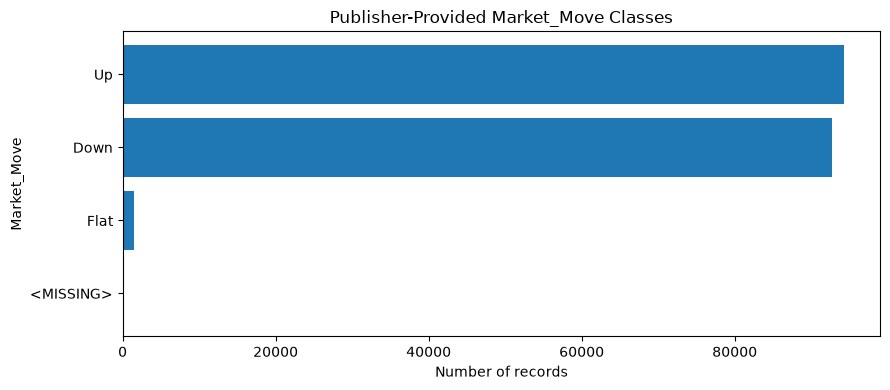

In [23]:
if "Market_Move" in v1_columns:
    market_move_counts = value_counts_streaming(
        V1_PATH,
        column="Market_Move",
        chunksize=20_000,
        dropna=False,
    )
    display(market_move_counts)
    plot_top_counts(
        market_move_counts,
        category_column="Market_Move",
        top_n=10,
        title="Publisher-Provided Market_Move Classes",
    )
else:
    market_move_counts = pd.DataFrame()
    print("Market_Move column is not available.")

## 18. OHLCV and market-field sanity checks

### Question

Are the publisher-provided market values internally plausible?

We check basic invariants such as:

- prices should normally be positive,
- volume should not be negative,
- `High` should not be below the other OHLC prices,
- `Low` should not be above the other OHLC prices,
- `Movement_OpenClose_%` should approximately agree with `(Close - Open) / Open * 100` when both are available.

These are **diagnostic checks**, not a replacement for the market-labeling methodology in Phase 5.

In [24]:
market_sanity = financial_sanity_checks(V1_PATH, chunksize=20_000)
market_sanity

,check,violations,rows_checked,violation_pct,notes
0,non_positive_price,0,188430,0.0000,Open/High/Low/Close should normally be positive.
1,negative_volume,0,188430,0.0000,Volume should normally be non-negative.
2,high_below_ohlc,0,188428,0.0000,"High should be >= Open, Low, and Close within a valid candle."
3,low_above_ohlc,0,188428,0.0000,"Low should be <= Open, High, and Close within a valid candle."
4,open_close_movement_mismatch,860,188428,0.4564,Stored Movement_OpenClose_% is compared with (Close-Open)/Open*100.


### Why this is scientifically important

If market fields contain inconsistencies, a model trained on them can learn noise while appearing to solve a meaningful financial task.

Even if these checks pass, we still need to answer later:

- What candle interval is represented?
- How was each article timestamp aligned to a candle?
- Was the market response measured before or after publication?
- Does the horizon match our desired 1h/4h/24h targets?

Those questions belong to Phase 5.

## 19. Numeric EDA on a random sample

Full-data sanity checks above answer whether basic rules are violated.

A random-sample descriptive summary is useful for seeing scale, skew, and extreme values without loading every market field into memory at once.

In [25]:
numeric_columns = [
    "sentiment_score",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Movement_OpenClose_%",
    "Movement_HighLow_%",
]

available_numeric_columns = [
    column for column in numeric_columns if column in v1_columns
]

if available_numeric_columns:
    numeric_sample_columns = list(dict.fromkeys(
        ["URL"] + available_numeric_columns
        if "URL" in v1_columns
        else available_numeric_columns
    ))

    numeric_sample = reservoir_sample_csv(
        V1_PATH,
        n=RANDOM_TEXT_SAMPLE_ROWS,
        columns=numeric_sample_columns,
        chunksize=CHUNK_SIZE,
        random_state=123,
    )

    display(numeric_summary(numeric_sample, available_numeric_columns))
else:
    print("No expected numeric columns were found.")

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing,missing_pct
sentiment_score,"20,000.0000",0.9456,0.0991,0.5001,0.5394,0.6905,0.9865,0.9990,0.9996,0.9999,0,0.0000
Open,"20,000.0000","19,739.5883","29,225.2901",0.0000,0.0275,0.2990,"3,518.9850","93,127.7750","109,014.7437","122,941.9300",0,0.0000
High,"20,000.0000","19,786.8016","29,286.2173",0.0000,0.0280,0.3002,"3,527.3050","93,355.7390","109,096.7898","123,584.4100",0,0.0000
Low,"20,000.0000","19,691.5431","29,162.2772",0.0000,0.0230,0.2969,"3,508.6050","92,858.0315","108,826.3839","122,910.6200",0,0.0000
Close,"20,000.0000","19,739.8797","29,225.1735",0.0000,0.0253,0.2987,"3,515.6350","92,998.0190","109,000.1443","123,518.7600",0,0.0000
Volume,"20,000.0000","1,737,036,428.1178","47,772,605,911.6179",0.0000,65.0495,142.2610,"2,415.6400","4,241,590.8300","162,707,703.9900","5,042,760,000,000.0000",0,0.0000
Movement_OpenClose_%,"20,000.0000",-0.0099,1.0011,-63.0356,-1.5089,-0.7105,0.0000,0.7020,1.4998,28.3746,0,0.0000
Movement_HighLow_%,"20,000.0000",0.7127,2.7104,0.0000,0.0850,0.1465,0.4789,1.7522,3.4315,202.7056,0,0.0000


# 20. Handoff to Phase 3 — Text Preprocessing

Phase 3 should receive the following information from this notebook:

1. the exact V1 schema actually observed,
2. the Bitcoin selection rule,
3. the chosen raw text field(s),
4. missing-text handling requirements,
5. deduplication candidates,
6. source/time biases that must remain visible during evaluation,
7. columns that must not become model features,
8. any data-quality limitations discovered here.
